1. Train the model and save it 

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg
import time
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define DeepONet model (consistent with original code)
class DeepONet(nn.Module):
    """DeepONet neural network model"""
    
    def __init__(self, branch_input_dim=36, trunk_input_dim=2, hidden_dim=256):
        super().__init__()
        
        # Branch network (processes system parameters)
        self.branch_net = nn.Sequential(
            nn.Linear(branch_input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, hidden_dim)
        )
        
        # Trunk network (processes position coordinates)
        self.trunk_net = nn.Sequential(
            nn.Linear(trunk_input_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, hidden_dim)
        )
        
        # Output layer
        self.output_layer = nn.Linear(hidden_dim, 1)
        
    def forward(self, branch_input, trunk_input):
        # Branch network processing
        branch_out = self.branch_net(branch_input)  # (batch_size, hidden_dim)
        
        # Trunk network processing
        batch_size, num_points, coord_dim = trunk_input.shape
        trunk_flat = trunk_input.view(-1, coord_dim)
        trunk_out = self.trunk_net(trunk_flat)  # (batch_size*num_points, hidden_dim)
        trunk_out = trunk_out.view(batch_size, num_points, -1)
        
        # DeepONet core operation: multiply branch and trunk outputs
        branch_out = branch_out.unsqueeze(1)  # (batch_size, 1, hidden_dim)
        combined = branch_out * trunk_out  # (batch_size, num_points, hidden_dim)
        
        # Final output
        output = self.output_layer(combined).squeeze(-1)  # (batch_size, num_points)
        return output

class ProgressiveDeepONet(nn.Module):
    """Progressive DeepONet - Extend from 3D to 4D, handling all Brunovsky decomposition cases"""
    
    def __init__(self, pretrained_model_path, hidden_dim=256):
        super().__init__()
        
        # Load pre-trained 3D model
        self.model_3d = DeepONet(branch_input_dim=36, trunk_input_dim=2, hidden_dim=hidden_dim)
        
        # Fix issue 1: use weights_only=True
        try:
            self.model_3d.load_state_dict(torch.load(pretrained_model_path, map_location=device, weights_only=True))
        except:
            # If version does not support weights_only, fallback to original method
            self.model_3d.load_state_dict(torch.load(pretrained_model_path, map_location=device))
        
        # Freeze parameters of pre-trained model
        for param in self.model_3d.parameters():
            param.requires_grad = False
        
        # Embedding layer: maps 64-dimensional input to 36 dimensions
        self.embedding_layer = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 36)
        )
        
        # Extension layer: maps 9-dimensional output to 16 dimensions
        self.extension_layer = nn.Sequential(
            nn.Linear(9, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 16)
        )
        
        # Fixed 3x3 grid for pre-trained model
        self.grid_3x3 = self.generate_position_grid(3, 3)
        
    def generate_position_grid(self, rows=3, cols=3):
        """Generate position coordinate grid"""
        grid = []
        for i in range(rows):
            for j in range(cols):
                # Normalized coordinates
                x_norm = i / (rows - 1) if rows > 1 else 0.5
                y_norm = j / (cols - 1) if cols > 1 else 0.5
                grid.append([x_norm, y_norm])
        return torch.FloatTensor(np.array(grid)).to(device)
        
    def forward(self, branch_input_4d, trunk_input_4x4=None):
        """
        branch_input_4d: 4D system input (batch_size, 64)
        trunk_input_4x4: 4x4 position coordinates (batch_size, 16, 2) - this parameter is not used now
        """
        batch_size = branch_input_4d.shape[0]
        
        # Embedding layer: 64D -> 36D
        branch_input_3d = self.embedding_layer(branch_input_4d)
        
        # Create 3x3 grid for 3D model
        grid_3x3_batch = self.grid_3x3.unsqueeze(0).repeat(batch_size, 1, 1)
        
        # Use pre-trained 3D model - output shape: (batch_size, 9)
        output_3d = self.model_3d(branch_input_3d, grid_3x3_batch)
        
        # Extension layer: 9D -> 16D
        output_4d = self.extension_layer(output_3d)  # (batch_size, 16)
        
        return output_4d

def verify_4d_stability_all_types(model, test_inputs, test_outputs):
    """Verify stability for all types of 4D systems"""
    model.eval()
    
    stability_results = []
    eigenvalue_data = []
    
    for idx in range(len(test_inputs)):
        # Extract system parameters from input data
        input_vector = test_inputs[idx]
        
        # Parse input vector (A, B, Q, R) - 4D
        A_flat = input_vector[:16]  # first 16 elements are A matrix
        B_flat = input_vector[16:32]  # next 16 elements are B matrix
        Q_flat = input_vector[32:48]  # next 16 elements are Q matrix
        R_flat = input_vector[48:64]  # last 16 elements are R matrix
        
        # Reshape to matrix form
        A = A_flat.reshape(4, 4)
        B = B_flat.reshape(4, 4)
        Q = Q_flat.reshape(4, 4)
        R = R_flat.reshape(4, 4)
        
        # Get true P matrix
        true_P_flat = test_outputs[idx]
        true_P = true_P_flat.reshape(4, 4)
        
        # Predict P matrix using model
        with torch.no_grad():
            input_tensor = torch.FloatTensor(input_vector).unsqueeze(0).to(device)
            pred_P_flat = model(input_tensor).cpu().numpy()[0]
            pred_P = pred_P_flat.reshape(4, 4)
        
        # Determine actual dimensions of B and R
        # Check number of non-zero columns in B matrix
        B_nonzero_cols = np.sum(np.any(B != 0, axis=0))
        if B_nonzero_cols == 1:
            # Type [4]: B is 4x1
            B_actual = B[:, 0:1]
            R_actual = np.array([[R[0, 0]]])
        elif B_nonzero_cols == 2:
            # Type [3,1] or [2,2]: B is 4x2
            B_actual = B[:, :2]
            R_actual = R[:2, :2]
        elif B_nonzero_cols == 3:
            # Type [2,1,1]: B is 4x3
            B_actual = B[:, :3]
            R_actual = R[:3, :3]
        else:
            # Type [1,1,1,1]: B is 4x4
            B_actual = B
            R_actual = R
        
        # Compute feedback gain matrix K = R^(-1) * B^T * P
        try:
            K_true = np.linalg.inv(R_actual) @ B_actual.T @ true_P
            K_pred = np.linalg.inv(R_actual) @ B_actual.T @ pred_P
        except:
            continue
        
        # Compute closed-loop system matrix A_cl = A - B * K
        A_cl_true = A - B_actual @ K_true
        A_cl_pred = A - B_actual @ K_pred
        
        # Compute eigenvalues
        eig_true = np.linalg.eig(A_cl_true)[0]
        eig_pred = np.linalg.eig(A_cl_pred)[0]
        
        # Check stability (all eigenvalues real part < 0)
        stable_true = np.all(eig_true.real < 0)
        stable_pred = np.all(eig_pred.real < 0)
        
        stability_results.append({
            'index': idx,
            'stable_true': stable_true,
            'stable_pred': stable_pred,
            'eig_true': eig_true,
            'eig_pred': eig_pred,
            'true_P': true_P,
            'pred_P': pred_P,
            'A': A,
            'B_actual': B_actual,
            'R_actual': R_actual,
            'Q': Q
        })
        
        # Collect eigenvalue data
        for eig in eig_true:
            eigenvalue_data.append({
                'real': eig.real,
                'imag': eig.imag,
                'type': 'True P',
                'stable': stable_true
            })
        for eig in eig_pred:
            eigenvalue_data.append({
                'real': eig.real,
                'imag': eig.imag,
                'type': 'Predicted P',
                'stable': stable_pred
            })
    
    return stability_results, eigenvalue_data

def analyze_stability_by_type(stability_results, test_inputs):
    """Analyze stability by Brunovsky type"""
    type_stability = {
        'Type [4]': {'total': 0, 'true_stable': 0, 'pred_stable': 0},
        'Type [3,1]': {'total': 0, 'true_stable': 0, 'pred_stable': 0},
        'Type [2,2]': {'total': 0, 'true_stable': 0, 'pred_stable': 0},
        'Type [2,1,1]': {'total': 0, 'true_stable': 0, 'pred_stable': 0},
        'Type [1,1,1,1]': {'total': 0, 'true_stable': 0, 'pred_stable': 0}
    }
    
    for i, result in enumerate(stability_results):
        # Identify type from input data
        input_vector = test_inputs[result['index']]
        B_flat = input_vector[16:32]
        B = B_flat.reshape(4, 4)
        
        # Count non-zero columns in B matrix
        B_nonzero_cols = np.sum(np.any(B != 0, axis=0))
        
        # Determine type based on B matrix structure
        if B_nonzero_cols == 1:
            type_key = 'Type [4]'
        elif B_nonzero_cols == 2:
            # Further distinguish between [3,1] and [2,2]
            A_flat = input_vector[:16]
            A = A_flat.reshape(4, 4)
            # Simple heuristic: check A matrix structure
            if A[2, 3] == 0 and A[3, 2] == 0:
                type_key = 'Type [2,2]'
            else:
                type_key = 'Type [3,1]'
        elif B_nonzero_cols == 3:
            type_key = 'Type [2,1,1]'
        else:
            type_key = 'Type [1,1,1,1]'
        
        # Update statistics
        type_stability[type_key]['total'] += 1
        if result['stable_true']:
            type_stability[type_key]['true_stable'] += 1
        if result['stable_pred']:
            type_stability[type_key]['pred_stable'] += 1
    
    return type_stability

if __name__ == "__main__":
    # Load saved data
    print("Loading data...")
    data_path = os.path.join("./4D", "brunovsky_data.npz")
    data = np.load(data_path)
    train_4d_inputs = data['train_inputs']
    train_4d_outputs = data['train_outputs']
    test_4d_inputs = data['test_inputs']
    test_4d_outputs = data['test_outputs']
    print(f"Training set: {len(train_4d_inputs)} samples, Test set: {len(test_4d_inputs)} samples")

    # Convert to PyTorch tensors
    train_branch_4d_tensor = torch.FloatTensor(train_4d_inputs).to(device)
    train_output_4d_tensor = torch.FloatTensor(train_4d_outputs).to(device)

    test_branch_4d_tensor = torch.FloatTensor(test_4d_inputs).to(device)
    test_output_4d_tensor = torch.FloatTensor(test_4d_outputs).to(device)

    # Create progressive model
    pretrained_path = '4D/riccati_deeponet.pth'  # Please ensure this file exists
    progressive_model = ProgressiveDeepONet(pretrained_path).to(device)

    # Train only the newly added layers (embedding and extension layers)
    trainable_params = []
    trainable_params.extend(progressive_model.embedding_layer.parameters())
    trainable_params.extend(progressive_model.extension_layer.parameters())

    # Training parameters
    num_epochs = 3000
    learning_rate = 1e-4

    # Optimizer (only optimizes newly added layers)
    optimizer = optim.Adam(trainable_params, lr=learning_rate, weight_decay=1e-5)
    criterion = nn.MSELoss()

    # Record training process
    train_losses = []
    test_losses = []
    epoch_times = []

    print("Starting training of progressive model...")

    # Record training start time
    total_start_time = time.time()

    for epoch in range(num_epochs):
        # Record epoch start time
        epoch_start_time = time.time()
        
        # Training phase
        progressive_model.train()
        optimizer.zero_grad()
        
        train_pred = progressive_model(train_branch_4d_tensor)
        train_loss = criterion(train_pred, train_output_4d_tensor)
        train_loss.backward()
        optimizer.step()
        
        # Testing phase
        progressive_model.eval()
        with torch.no_grad():
            test_pred = progressive_model(test_branch_4d_tensor)
            test_loss = criterion(test_pred, test_output_4d_tensor)
        
        # Record losses
        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        
        # Record epoch end time
        epoch_end_time = time.time()
        epoch_time = epoch_end_time - epoch_start_time
        epoch_times.append(epoch_time)
        
        # Print progress
        if (epoch + 1) % 100 == 0:
            avg_epoch_time = sum(epoch_times[-100:]) / 100
            print(f'Epoch [{epoch+1}/{num_epochs}], '
                  f'Train Loss: {train_loss.item():.6f}, '
                  f'Test Loss: {test_loss.item():.6f}, '
                  f'Epoch time: {epoch_time:.2f}s, '
                  f'Average epoch time: {avg_epoch_time:.2f}s')

    # Record training end time
    total_end_time = time.time()
    total_time = total_end_time - total_start_time

    hours = int(total_time // 3600)
    minutes = int((total_time % 3600) // 60)
    seconds = total_time % 60

    print(f"Training completed! Total training time: {hours}h {minutes}m {seconds:.2f}s")
    print(f"Total training time (seconds): {total_time:.2f}")
    print(f"Average epoch time: {sum(epoch_times)/len(epoch_times):.2f}s")
    print(f"Fastest epoch time: {min(epoch_times):.2f}s")
    print(f"Slowest epoch time: {max(epoch_times):.2f}s")

    # Specify folder name
    save_dir = '4D'

    # Construct full file save path
    save_path = os.path.join(save_dir, 'deeponet_progressive_model.pth')
    # Save model
    torch.save(progressive_model.state_dict(), save_path)
    print(f"Progressive model saved as '{save_path}'")

    # Final test
    print("\nFinal test results (all 4D system types):")
    progressive_model.eval()
    with torch.no_grad():
        test_predictions = progressive_model(test_branch_4d_tensor)
        final_test_loss = criterion(test_predictions, test_output_4d_tensor)
        mae = torch.mean(torch.abs(test_predictions - test_output_4d_tensor))
        
        print(f"Final test loss (MSE): {final_test_loss.item():.6f}")
        print(f"Mean Absolute Error (MAE): {mae.item():.6f}")

    # Verify stability for all types of 4D systems
    print("\nStarting stability verification for all types of 4D systems...")
    stability_results_4d, eigenvalue_data_4d = verify_4d_stability_all_types(
        progressive_model, test_4d_inputs, test_4d_outputs
    )

    # Compute stability statistics
    true_stable_count = sum(1 for r in stability_results_4d if r['stable_true'])
    pred_stable_count = sum(1 for r in stability_results_4d if r['stable_pred'])
    total_count = len(stability_results_4d)

    print(f"\nStability verification results for all types of 4D systems:")
    print(f"Systems stable with true P matrix: {true_stable_count}/{total_count} ({true_stable_count/total_count*100:.1f}%)")
    print(f"Systems stable with predicted P matrix: {pred_stable_count}/{total_count} ({pred_stable_count/total_count*100:.1f}%)")

    # Analyze stability by type
    type_stability = analyze_stability_by_type(stability_results_4d, test_4d_inputs)
    print("\nStability analysis by type:")
    for type_name, stats in type_stability.items():
        if stats['total'] > 0:
            true_rate = stats['true_stable'] / stats['total'] * 100
            pred_rate = stats['pred_stable'] / stats['total'] * 100
            print(f"{type_name}: {stats['total']} systems, true stable {true_rate:.1f}%, predicted stable {pred_rate:.1f}%")

    print("\nProgressive transfer learning for all types of 4D systems completed!")

    # Count proportion of closed-loop eigenvalues with negative real parts
    total_true_eigs = 0
    negative_true_eigs = 0
    total_pred_eigs = 0
    negative_pred_eigs = 0

    for result in stability_results_4d:
        for eig in result['eig_true']:
            total_true_eigs += 1
            if eig.real < 0:
                negative_true_eigs += 1
        for eig in result['eig_pred']:
            total_pred_eigs += 1
            if eig.real < 0:
                negative_pred_eigs += 1

    print(f"\nProportion of closed-loop eigenvalues with negative real parts:")
    print(f"True closed-loop eigenvalues: {negative_true_eigs}/{total_true_eigs} = {negative_true_eigs/total_true_eigs*100:.2f}%")
    print(f"Predicted closed-loop eigenvalues: {negative_pred_eigs}/{total_pred_eigs} = {negative_pred_eigs/total_pred_eigs*100:.2f}%")

Using device: cuda
Loading data...
Training set: 19000 samples, Test set: 1000 samples
Starting training of progressive model...
Epoch [100/3000], Train Loss: 3.964234, Test Loss: 4.324628, Epoch time: 0.02s, Average epoch time: 0.02s
Epoch [200/3000], Train Loss: 1.586448, Test Loss: 1.765718, Epoch time: 0.02s, Average epoch time: 0.02s
Epoch [300/3000], Train Loss: 0.906739, Test Loss: 0.974025, Epoch time: 0.02s, Average epoch time: 0.02s
Epoch [400/3000], Train Loss: 0.692255, Test Loss: 0.745408, Epoch time: 0.02s, Average epoch time: 0.02s
Epoch [500/3000], Train Loss: 0.522154, Test Loss: 0.552945, Epoch time: 0.02s, Average epoch time: 0.02s
Epoch [600/3000], Train Loss: 0.441830, Test Loss: 0.462994, Epoch time: 0.02s, Average epoch time: 0.02s
Epoch [700/3000], Train Loss: 0.391738, Test Loss: 0.411695, Epoch time: 0.02s, Average epoch time: 0.02s
Epoch [800/3000], Train Loss: 0.350121, Test Loss: 0.370858, Epoch time: 0.02s, Average epoch time: 0.02s
Epoch [900/3000], Train

In [6]:
# Count model parameters
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(progressive_model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")


Total parameters: 403,829
Trainable parameters: 22,388
Frozen parameters: 381,441


In [10]:
# ============================================================
# Output detailed information of unstable predictions (eigenvalues with real part ≥ 0)
# ============================================================
print("\n" + "="*60)
print("Detailed information of unstable predictions (eigenvalue real part ≥ 0)")
print("="*60)

unstable_count = 0
for result in stability_results_4d:
    if not result['stable_pred']:                     # only care about systems predicted unstable
        unstable_count += 1
        idx = result['index']
        print(f"\nSample index {idx} (predicted unstable)")
        
        # Find eigenvalues with real part ≥ 0 among predicted eigenvalues
        eig_pred = result['eig_pred']
        unstable_eigs = [e for e in eig_pred if e.real >= 0]
        
        # Output all predicted eigenvalues (real parts)
        pred_real_parts = [f"{e.real:.4f}" for e in eig_pred]
        print(f"  All predicted eigenvalue real parts : {pred_real_parts}")
        
        # Output unstable predicted eigenvalues (real and imaginary parts)
        unstable_str = []
        for e in unstable_eigs:
            if abs(e.imag) < 1e-8:
                unstable_str.append(f"{e.real:.4f}")
            else:
                unstable_str.append(f"{e.real:.4f} + {e.imag:.4f}j")
        print(f"  Unstable eigenvalues       : {unstable_str}")
        
        # Output true eigenvalues for comparison
        true_real_parts = [f"{e.real:.4f}" for e in result['eig_true']]
        print(f"  True eigenvalue real parts     : {true_real_parts}")
        print(f"  True system stable   : {result['stable_true']}")
        
        # If you want to view specific matrices, uncomment the following lines
        # print(f"  A matrix:\n{result['A']}")
        # print(f"  B_actual matrix:\n{result['B_actual']}")
        # print(f"  R_actual matrix:\n{result['R_actual']}")

print(f"\nTotal {unstable_count} systems predicted unstable.")


Detailed information of unstable predictions (eigenvalue real part ≥ 0)

Sample index 15 (predicted unstable)
  All predicted eigenvalue real parts : ['-5.0190', '-0.8515', '-0.8515', '0.1527']
  Unstable eigenvalues       : ['0.1527']
  True eigenvalue real parts     : ['-2.6997', '-0.7584', '-0.7584', '-0.4524']
  True system stable   : True

Sample index 43 (predicted unstable)
  All predicted eigenvalue real parts : ['-1.6978', '-1.6978', '-0.6379', '0.1077']
  Unstable eigenvalues       : ['0.1077']
  True eigenvalue real parts     : ['-3.1129', '-1.0419', '-0.4203', '-0.4203']
  True system stable   : True

Sample index 44 (predicted unstable)
  All predicted eigenvalue real parts : ['-1.3620', '-1.3620', '-0.6862', '0.1001']
  Unstable eigenvalues       : ['0.1001']
  True eigenvalue real parts     : ['-1.1258', '-1.1258', '-0.6641', '-0.6014']
  True system stable   : True

Sample index 181 (predicted unstable)
  All predicted eigenvalue real parts : ['-1.9907', '-0.6485', '-0

2. Time for 3 methods

Using device: cuda
Test set size: 1000
Standard DeepONet loaded.
Progressive DeepONet loaded.

Using 500 random test samples for timing.

Measuring CARE solving time...
  CARE: 100/500
  CARE: 200/500
  CARE: 300/500
  CARE: 400/500
  CARE: 500/500
  CARE average: 0.5685 ms/sample ± 0.1284

Timing Standard DeepONet (single-sample loop)...
    100/500
    200/500
    300/500
    400/500
    500/500
  Standard DeepONet single-sample average: 0.4352 ms/sample ± 0.2326
Timing Standard DeepONet (batch)...
  Standard DeepONet batch average: 0.0020 ms/sample

Timing Progressive DeepONet (single-sample loop)...
    100/500
    200/500
    300/500
    400/500
    500/500
  Progressive DeepONet single-sample average: 0.7838 ms/sample ± 0.5422
Timing Progressive DeepONet (batch)...
  Progressive DeepONet batch average: 0.0016 ms/sample


Speed comparison summary (n=4, batch inference for DeepONets)
----------------------------------------------------------------------
Method                      

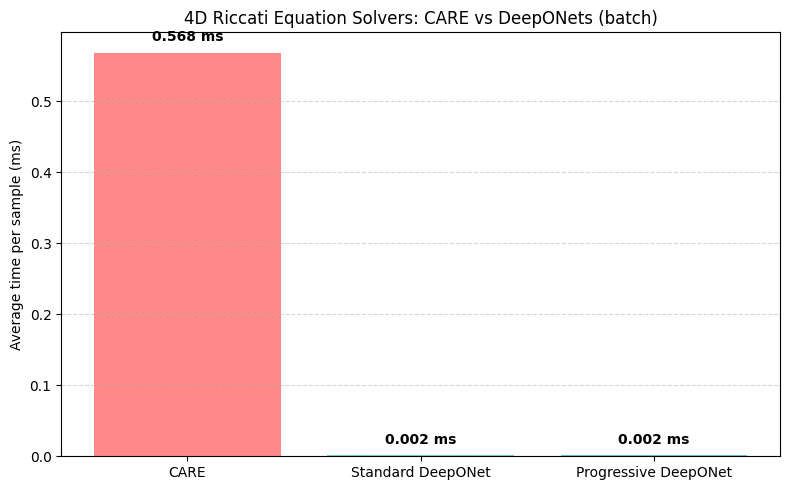

Plot saved to ./4D\speed_comparison_all_models.png


In [10]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import scipy.linalg

# -------------------- Device setup --------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# -------------------- Define model architectures --------------------
class StandardDeepONet(nn.Module):
    """Standard DeepONet for 4D systems (branch:64, trunk:2, output:16 points)"""
    def __init__(self, branch_input_dim=64, trunk_input_dim=2, hidden_dim=512):
        super().__init__()
        self.branch_net = nn.Sequential(
            nn.Linear(branch_input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, hidden_dim)
        )
        self.trunk_net = nn.Sequential(
            nn.Linear(trunk_input_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, hidden_dim)
        )
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, branch_input, trunk_input):
        branch_out = self.branch_net(branch_input)
        batch_size, num_points, coord_dim = trunk_input.shape
        trunk_flat = trunk_input.reshape(-1, coord_dim)
        trunk_out = self.trunk_net(trunk_flat)
        trunk_out = trunk_out.view(batch_size, num_points, -1)
        branch_out = branch_out.unsqueeze(1)
        combined = branch_out * trunk_out
        output = self.output_layer(combined).squeeze(-1)
        return output

class DeepONet3D(nn.Module):
    """3D DeepONet (branch:36, trunk:2, output:9 points) – used inside progressive model"""
    def __init__(self, branch_input_dim=36, trunk_input_dim=2, hidden_dim=256):
        super().__init__()
        self.branch_net = nn.Sequential(
            nn.Linear(branch_input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, hidden_dim)
        )
        self.trunk_net = nn.Sequential(
            nn.Linear(trunk_input_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, hidden_dim)
        )
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, branch_input, trunk_input):
        branch_out = self.branch_net(branch_input)
        batch_size, num_points, coord_dim = trunk_input.shape
        trunk_flat = trunk_input.reshape(-1, coord_dim)
        trunk_out = self.trunk_net(trunk_flat)
        trunk_out = trunk_out.view(batch_size, num_points, -1)
        branch_out = branch_out.unsqueeze(1)
        combined = branch_out * trunk_out
        output = self.output_layer(combined).squeeze(-1)
        return output

class ProgressiveDeepONet(nn.Module):
    """Progressive DeepONet (embeds 64→36, uses 3D model, extends 9→16)"""
    def __init__(self, pretrained_3d_path=None, hidden_dim=256):
        super().__init__()
        self.model_3d = DeepONet3D(branch_input_dim=36, trunk_input_dim=2, hidden_dim=hidden_dim)
        if pretrained_3d_path is not None and os.path.exists(pretrained_3d_path):
            state_dict = torch.load(pretrained_3d_path, map_location=device)
            self.model_3d.load_state_dict(state_dict)
        for param in self.model_3d.parameters():
            param.requires_grad = False

        self.embedding_layer = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 36)
        )
        self.extension_layer = nn.Sequential(
            nn.Linear(9, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 16)
        )
        # 3x3 grid (normalized)
        grid = []
        for i in range(3):
            for j in range(3):
                x_norm = i / 2.0
                y_norm = j / 2.0
                grid.append([x_norm, y_norm])
        self.register_buffer("grid_3x3", torch.FloatTensor(grid))

    def forward(self, branch_input_4d):
        batch_size = branch_input_4d.shape[0]
        branch_3d = self.embedding_layer(branch_input_4d)                # (B,36)
        grid_batch = self.grid_3x3.unsqueeze(0).repeat(batch_size, 1, 1) # (B,9,2)
        out_3d = self.model_3d(branch_3d, grid_batch)                    # (B,9)
        out_4d = self.extension_layer(out_3d)                            # (B,16)
        return out_4d

# -------------------- Helper: recover A, B, Q, R from 64-dim input --------------------
def recover_matrices(input_vec):
    A = input_vec[:16].reshape(4, 4)
    B_padded = input_vec[16:32].reshape(4, 4)
    Q = input_vec[32:48].reshape(4, 4)
    R_padded = input_vec[48:64].reshape(4, 4)
    # Determine m by counting non-zero columns in B_padded
    nonzero_cols = np.where(np.any(B_padded != 0, axis=0))[0]
    m = len(nonzero_cols) if len(nonzero_cols) > 0 else 4
    B = B_padded[:, :m]
    R = R_padded[:m, :m]
    return A, B, Q, R

# -------------------- Load test data --------------------
data_dir = "./4D"
data_path = os.path.join(data_dir, "brunovsky_data.npz")
data = np.load(data_path)
test_inputs = data['test_inputs']      # (N, 64)
print(f"Test set size: {len(test_inputs)}")

# -------------------- Load models --------------------
# Standard DeepONet
std_model = StandardDeepONet().to(device)
std_path = os.path.join(data_dir, "deeponet_standard_model.pth")
if os.path.exists(std_path):
    std_model.load_state_dict(torch.load(std_path, map_location=device))
    print("Standard DeepONet loaded.")
else:
    raise FileNotFoundError(f"Standard model not found at {std_path}")

# Progressive DeepONet
prog_model = ProgressiveDeepONet(pretrained_3d_path=None).to(device)
prog_path = os.path.join(data_dir, "deeponet_progressive_model.pth")
if os.path.exists(prog_path):
    prog_model.load_state_dict(torch.load(prog_path, map_location=device), strict=False)
    print("Progressive DeepONet loaded.")
else:
    raise FileNotFoundError(f"Progressive model not found at {prog_path}")

# Set both to eval mode
std_model.eval()
prog_model.eval()

# -------------------- Prepare grid for standard DeepONet --------------------
# 4x4 grid (16 points) as used in training
def generate_grid_4x4():
    grid = []
    for i in range(4):
        for j in range(4):
            x_norm = i / 3.0
            y_norm = j / 3.0
            grid.append([x_norm, y_norm])
    return np.array(grid)

grid_4x4 = generate_grid_4x4()                       # (16,2)
grid_tensor = torch.FloatTensor(grid_4x4).to(device) # (16,2)

# -------------------- Select random test subset --------------------
num_samples = 500
np.random.seed(42)   # for reproducibility
indices = np.random.choice(len(test_inputs), size=num_samples, replace=False)
branch_inputs = test_inputs[indices]                 # (num_samples, 64)

# Pre‑extract (A,B,Q,R) for CARE solving
systems = [recover_matrices(branch_inputs[i]) for i in range(num_samples)]

print(f"\nUsing {num_samples} random test samples for timing.\n")

# -------------------- 1. CARE sequential solving --------------------
print("Measuring CARE solving time...")
care_times = []
for i, (A, B, Q, R) in enumerate(systems):
    start = time.perf_counter()
    _ = scipy.linalg.solve_continuous_are(A, B, Q, R)
    care_times.append(time.perf_counter() - start)
    if (i+1) % 100 == 0:
        print(f"  CARE: {i+1}/{num_samples}")
care_avg_ms = np.mean(care_times) * 1000
care_std_ms = np.std(care_times) * 1000
print(f"  CARE average: {care_avg_ms:.4f} ms/sample ± {care_std_ms:.4f}\n")

# -------------------- Helper for timing --------------------
def time_model(model, branch_inputs, batch_mode=False, is_standard=True):
    """
    Measure inference time for a model.
    For standard model: requires trunk input (grid_4x4).
    For progressive model: only branch input.
    """
    times = []
    if batch_mode:
        # Batch inference: single forward pass over all samples
        batch_tensor = torch.FloatTensor(branch_inputs).to(device)
        if is_standard:
            grid_batch = grid_tensor.unsqueeze(0).expand(len(branch_inputs), -1, -1)
        else:
            grid_batch = None
        # Warm-up
        with torch.no_grad():
            if is_standard:
                _ = model(batch_tensor[:min(10, len(branch_inputs))],
                          grid_batch[:min(10, len(branch_inputs))])
            else:
                _ = model(batch_tensor[:min(10, len(branch_inputs))])
        # Timing
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        with torch.no_grad():
            if is_standard:
                _ = model(batch_tensor, grid_batch)
            else:
                _ = model(batch_tensor)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        total_time = time.perf_counter() - start
        avg_ms = total_time / len(branch_inputs) * 1000
        return avg_ms, 0.0   # no std for batch
    else:
        # Single‑sample loop
        for i, inp in enumerate(branch_inputs):
            inp_tensor = torch.FloatTensor(inp).unsqueeze(0).to(device)
            if is_standard:
                grid_batch = grid_tensor.unsqueeze(0)   # (1,16,2)
                start = time.perf_counter()
                with torch.no_grad():
                    _ = model(inp_tensor, grid_batch)
                times.append(time.perf_counter() - start)
            else:
                start = time.perf_counter()
                with torch.no_grad():
                    _ = model(inp_tensor)
                times.append(time.perf_counter() - start)
            if (i+1) % 100 == 0:
                print(f"    {i+1}/{num_samples}")
        avg_ms = np.mean(times) * 1000
        std_ms = np.std(times) * 1000
        return avg_ms, std_ms

# -------------------- 2. Standard DeepONet timing --------------------
print("Timing Standard DeepONet (single-sample loop)...")
std_single_avg, std_single_std = time_model(std_model, branch_inputs, batch_mode=False, is_standard=True)
print(f"  Standard DeepONet single-sample average: {std_single_avg:.4f} ms/sample ± {std_single_std:.4f}")

print("Timing Standard DeepONet (batch)...")
std_batch_avg, _ = time_model(std_model, branch_inputs, batch_mode=True, is_standard=True)
print(f"  Standard DeepONet batch average: {std_batch_avg:.4f} ms/sample\n")

# -------------------- 3. Progressive DeepONet timing --------------------
print("Timing Progressive DeepONet (single-sample loop)...")
prog_single_avg, prog_single_std = time_model(prog_model, branch_inputs, batch_mode=False, is_standard=False)
print(f"  Progressive DeepONet single-sample average: {prog_single_avg:.4f} ms/sample ± {prog_single_std:.4f}")

print("Timing Progressive DeepONet (batch)...")
prog_batch_avg, _ = time_model(prog_model, branch_inputs, batch_mode=True, is_standard=False)
print(f"  Progressive DeepONet batch average: {prog_batch_avg:.4f} ms/sample\n")

# -------------------- Summary table (using batch mode for both DeepONets) --------------------
print("\n" + "="*70)
print("Speed comparison summary (n=4, batch inference for DeepONets)")
print("-"*70)
print(f"{'Method':<30} {'Time (ms)':<15} {'Speedup vs CARE':<20}")
print("-"*70)
print(f"{'CARE (sequential)':<30} {care_avg_ms:<15.8f} {'1.00':<20}")
print(f"{'Standard DeepONet (batch)':<30} {std_batch_avg:<15.8f} {care_avg_ms/std_batch_avg:<20.8f}")
print(f"{'Progressive DeepONet (batch)':<30} {prog_batch_avg:<15.8f} {care_avg_ms/prog_batch_avg:<20.8f}")
print("="*70)

# Optionally also print single‑sample results
print("\nSingle‑sample inference times (loop):")
print(f"  Standard DeepONet: {std_single_avg:.8f} ms/sample")
print(f"  Progressive DeepONet: {prog_single_avg:.8f} ms/sample")

# -------------------- Save results to CSV --------------------
import pandas as pd
results = pd.DataFrame({
    'Method': ['CARE', 'Standard DeepONet (batch)', 'Progressive DeepONet (batch)'],
    'Time_ms': [care_avg_ms, std_batch_avg, prog_batch_avg],
    'Speedup_vs_CARE': [1.0, care_avg_ms/std_batch_avg, care_avg_ms/prog_batch_avg]
})
csv_path = os.path.join(data_dir, "speed_comparison_all_models.csv")
results.to_csv(csv_path, index=False)
print(f"\nResults saved to {csv_path}")

# -------------------- Optional: bar plot --------------------
try:
    import matplotlib.pyplot as plt
    methods = ['CARE', 'Standard DeepONet', 'Progressive DeepONet']
    times = [care_avg_ms, std_batch_avg, prog_batch_avg]
    plt.figure(figsize=(8,5))
    bars = plt.bar(methods, times, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
    for bar, t in zip(bars, times):
        plt.text(bar.get_x() + bar.get_width()/2., t + 0.02*max(times),
                 f'{t:.3f} ms', ha='center', va='bottom', fontweight='bold')
    plt.ylabel('Average time per sample (ms)')
    plt.title('4D Riccati Equation Solvers: CARE vs DeepONets (batch)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plot_path = os.path.join(data_dir, "speed_comparison_all_models.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"Plot saved to {plot_path}")
except ImportError:
    print("matplotlib not available, skipping plot.")